In [4]:
import pandas as pd
import os
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
path = r"C:\Users\Nonso_Fidelis\Desktop\Nonso Fidelis 2026\stocks-data-main\cache\constituent_data"

files = glob(os.path.join(path, "*.csv"))

dfs = []

for file in files:
    df = pd.read_csv(file)
    ticker = os.path.basename(file).replace(".csv","")

    if "Symbol" not in df.columns:
        df["Symbol"] = ticker
    dfs.append(df)

stocks = pd.concat(dfs, ignore_index=True)

In [5]:
stocks.shape

(3508219, 7)

In [6]:
stocks

,Date,Symbol,Open,High,Low,Close,Volume
0,1999-11-18,A,29.5594,32.4842,25.9889,28.5858,6.886678e+07
1,1999-11-19,A,27.8972,27.9371,25.8613,26.2311,1.677358e+07
2,1999-11-22,A,26.8370,28.5858,26.0278,28.5858,7.242576e+06
3,1999-11-23,A,27.6102,28.3377,25.9889,25.9889,6.579458e+06
4,1999-11-24,A,26.0637,27.2445,25.9889,26.6745,5.332648e+06
...,...,...,...,...,...,...,...
3508214,2026-03-03,ZTS,127.7450,127.7500,125.2650,125.9500,1.383840e+05
3508215,2026-03-04,ZTS,126.1500,126.9000,124.9050,126.0150,2.324550e+05
3508216,2026-03-05,ZTS,124.8500,125.4100,122.0500,122.2200,2.237510e+05
3508217,2026-03-06,ZTS,120.1550,121.8300,118.3600,121.4150,1.677120e+05


### Overall Market Volatility Over Time

In [7]:
stocks["Date"] = pd.to_datetime(stocks["Date"])

stocks = stocks.sort_values(["Symbol","Date"])

In [8]:
stocks

,Date,Symbol,Open,High,Low,Close,Volume
0,1999-11-18,A,29.5594,32.4842,25.9889,28.5858,6.886678e+07
1,1999-11-19,A,27.8972,27.9371,25.8613,26.2311,1.677358e+07
2,1999-11-22,A,26.8370,28.5858,26.0278,28.5858,7.242576e+06
3,1999-11-23,A,27.6102,28.3377,25.9889,25.9889,6.579458e+06
4,1999-11-24,A,26.0637,27.2445,25.9889,26.6745,5.332648e+06
...,...,...,...,...,...,...,...
3508214,2026-03-03,ZTS,127.7450,127.7500,125.2650,125.9500,1.383840e+05
3508215,2026-03-04,ZTS,126.1500,126.9000,124.9050,126.0150,2.324550e+05
3508216,2026-03-05,ZTS,124.8500,125.4100,122.0500,122.2200,2.237510e+05
3508217,2026-03-06,ZTS,120.1550,121.8300,118.3600,121.4150,1.677120e+05


#### Lets create Create Daily Volatility, we will use daily trading range. This measures the difference between the day's highest and lowest price.

In [9]:
stocks["Volatility"] = stocks["High"] - stocks["Low"]

### Lets also visalize monthly volatility

In [10]:
stocks["YearMonth"] = stocks["Date"].dt.to_period("M")

monthly_volatility = (stocks.groupby("YearMonth")["Volatility"].mean())

<Axes: title={'center': 'Average Monthly Stock Volatility'}, xlabel='Year', ylabel='Average Daily Price Range'>

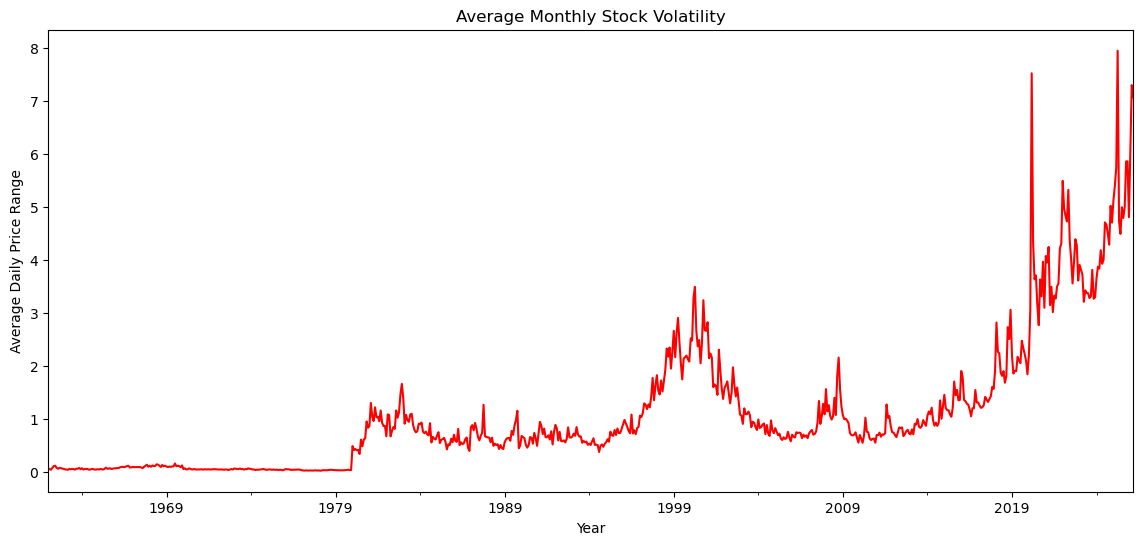

In [11]:
monthly_volatility.plot(figsize=(14,6),title="Average Monthly Stock Volatility",\
                        xlabel="Year",ylabel="Average Daily Price Range",
                        color="red")


#### Average monthly volatility measures how much stock prices fluctuated within each trading day across all companies. Rising values indicate periods of greater market uncertainty and larger price swings, while lower values suggest a more stable market with smaller daily movements.

<Axes: title={'center': '12-Month Rolling Average Market Volatility'}, xlabel='Year', ylabel='Average Daily Price Range'>

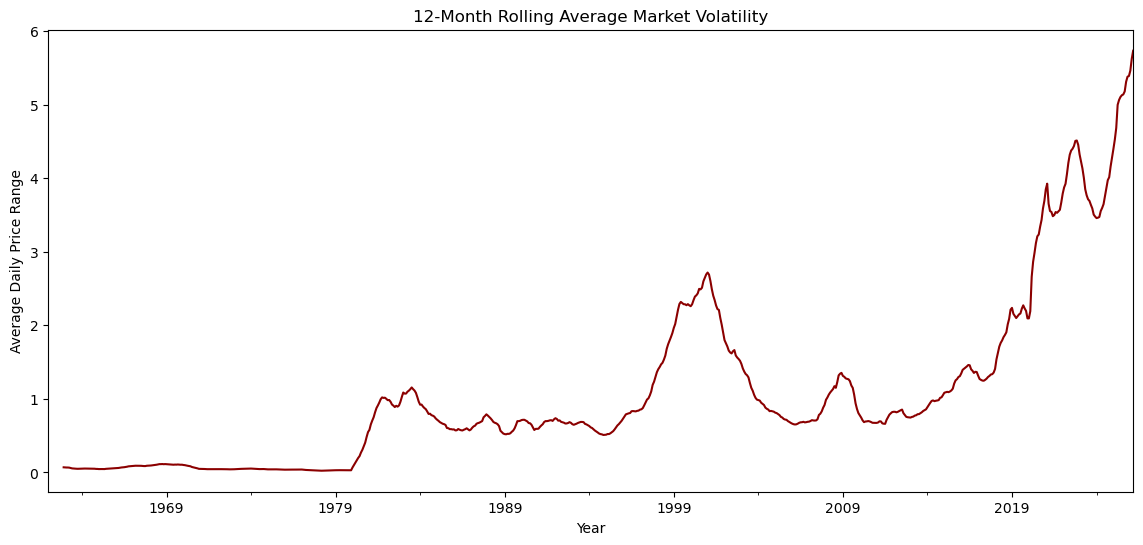

In [12]:
monthly_volatility.rolling(12).mean().plot(figsize=(14,6),title="12-Month Rolling Average Market Volatility",
                                           xlabel="Year",
                                           ylabel="Average Daily Price Range",color="darkred")

#### Lets also check the most Volatile years
This will simply identify the years in which the market experienced the largest average daily price fluctuations, highlighting periods of heightened uncertainty and investor activity.

In [13]:
stocks["Year"] = stocks["Date"].dt.year

yearly_volatility = (stocks.groupby("Year")["Volatility"].mean().sort_values(ascending=False))
yearly_volatility.head(15)

Year
2026    6.688322
2025    5.388819
2022    4.441482
2024    4.280101
2020    3.703494
2021    3.668993
2023    3.479647
2000    2.689320
1999    2.268810
2018    2.203778
2019    2.098537
1998    1.901394
2001    1.887513
2002    1.519353
2008    1.358614
Name: Volatility, dtype: float64

## Most Volatile Stocks - Just top 20
Reveals the stocks with the greatest average day-to-day price fluctuations, which may present higher trading opportunities but also carry greater investment risk.¶

In [14]:
stock_volatility = (stocks.groupby("Symbol")["Volatility"].mean().sort_values(ascending=False))
stock_volatility.head(20)

Symbol
NVR     65.917690
DAL     62.309011
BKNG    34.038882
GEV     17.235825
SNDK    14.065563
MTD     12.904744
AZO     12.606414
COIN    11.123733
FICO     9.416727
REGN     9.348510
CRWD     9.255347
APP      9.069690
TDG      8.013505
AIG      7.968892
EQIX     7.915757
BLK      7.632490
CHTR     7.276472
CVNA     7.241665
MPWR     6.865769
CEG      6.837357
Name: Volatility, dtype: float64

## Heatmap of Volatility by Year and Month
This quickly reveals years and months with unusually high volatility.

Text(0.5, 1.0, 'Monthly Market Volatility Heatmap')

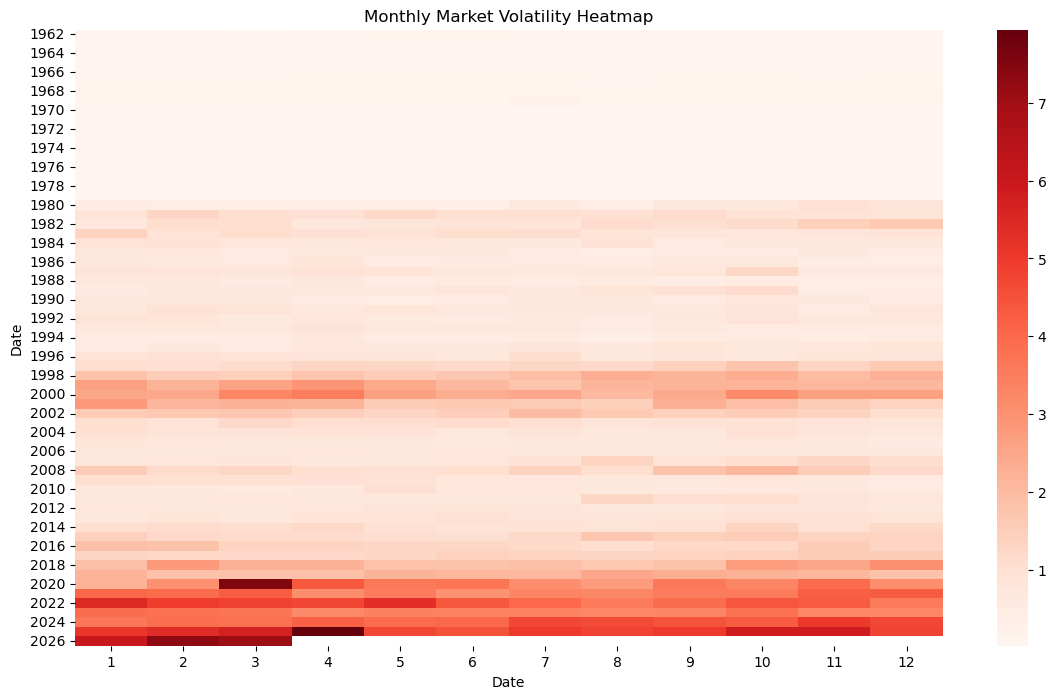

In [15]:
heat = (stocks.pivot_table(index=stocks["Date"].dt.year,columns=stocks["Date"].dt.month,values="Volatility",
        aggfunc="mean"))

plt.figure(figsize=(14,8))
sns.heatmap(heat, cmap="Reds")
plt.title("Monthly Market Volatility Heatmap")

# MACHINE LEARNING PART

### Feature Engineering - This will create the features that a ML models can learn from.

In [16]:
stocks["DailyReturn"] = stocks.groupby("Symbol")["Close"].pct_change()

stocks["MA5"] = stocks.groupby("Symbol")["Close"].rolling(5).mean().reset_index(level=0, drop=True)

stocks["MA20"] = stocks.groupby("Symbol")["Close"].rolling(20).mean().reset_index(level=0, drop=True)

stocks["MA50"] = stocks.groupby("Symbol")["Close"].rolling(50).mean().reset_index(level=0, drop=True)

stocks["RollingVolatility"] = stocks.groupby("Symbol")["DailyReturn"].rolling(20).std().reset_index(level=0, drop=True)

stocks["PriceRange"] = stocks["High"] - stocks["Low"]

## Now we want to create Tomorrow's Volatility - which is our Target Variable

#### Tomorrow's volatility is used as the prediction target, allowing the model to learn today's market conditions and forecast how volatile the stock is likely to be on the next trading day.

In [17]:
stocks["TomorrowVolatility"] = (stocks.groupby("Symbol")["PriceRange"].shift(-1))

#### Determine the Cutoff Points, then we'll split the data into thirds.

In [18]:
low = stocks["TomorrowVolatility"].quantile(0.33)
high = stocks["TomorrowVolatility"].quantile(0.66)

print(low, high)

0.3249999999999993 1.0150000000000006


In [19]:
import numpy as np

stocks["VolatilityLevel"] = np.select([stocks["TomorrowVolatility"] < low, stocks["TomorrowVolatility"] < high],
                                      ["Low", "Medium"], default="High")

In [20]:
stocks["VolatilityLevel"].value_counts()

VolatilityLevel
High      1193217
Medium    1157901
Low       1157101
Name: count, dtype: int64

### Visualizing the Volatility Level Distribution

Text(0, 0.5, 'Number of Records')

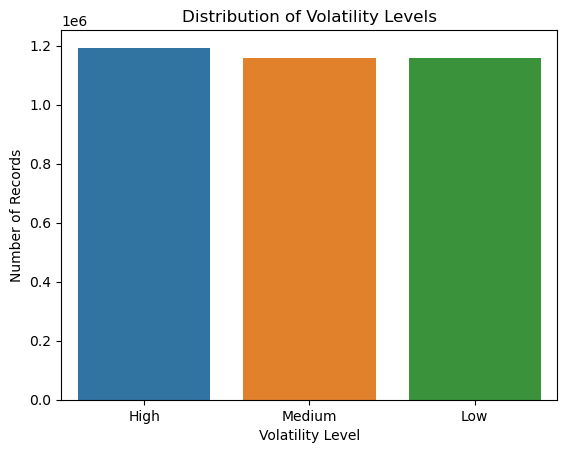

In [21]:
sns.countplot(data=stocks, x="VolatilityLevel")

plt.title("Distribution of Volatility Levels")
plt.xlabel("Volatility Level")
plt.ylabel("Number of Records")

## Feature Selection 

In [22]:
features = ["Open","High","Low","Close","Volume","DailyReturn","MA5","MA20","MA50","RollingVolatility","PriceRange"]
stocks = stocks.dropna(subset=features + ["VolatilityLevel"])

X = stocks[features]
y = stocks["VolatilityLevel"]

## Train-Test Split at 80:20

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### Feature Scaling of the Data

### Feature scaling standardizes the variables to a common scale, improving the performance

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LOGISTIC REGRESSION

##### Logistic Regression serves as a baseline machine learning model by estimating the probability that each observation belongs to a particular volatility class.

In [25]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

# DECISION TREE

##### Decision Trees classify stock volatility by learning a sequence of decision rules from historical market data.

In [26]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42,max_depth=10)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# EVALUATION

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
    ],
    "Precision":[
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
    ],
    "Recall":[
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
    ],
    "F1 Score":[
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8218,0.8257,0.8218,0.8229
1,Decision Tree,0.8291,0.8342,0.8291,0.8308


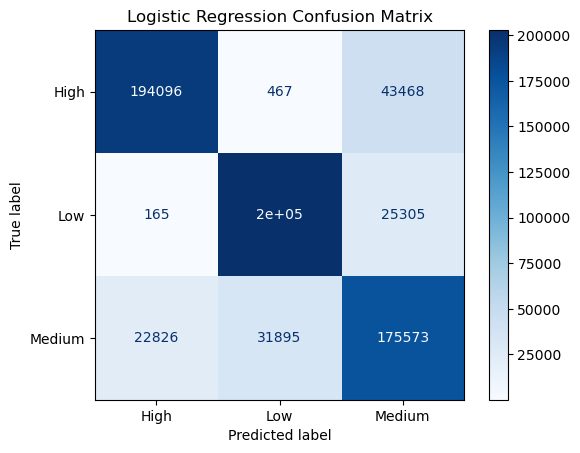

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

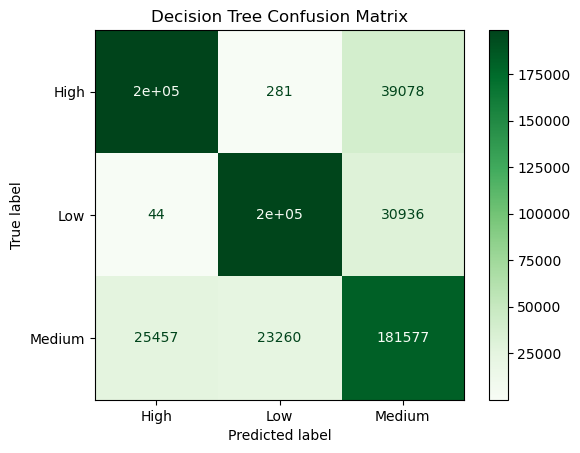

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [30]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

        High       0.89      0.82      0.85    238031
         Low       0.86      0.89      0.88    228311
      Medium       0.72      0.76      0.74    230294

    accuracy                           0.82    696636
   macro avg       0.83      0.82      0.82    696636
weighted avg       0.83      0.82      0.82    696636



In [31]:
print("Decision Tree")
print(classification_report(y_test, dt_pred))

Decision Tree
              precision    recall  f1-score   support

        High       0.89      0.83      0.86    238031
         Low       0.89      0.86      0.88    228311
      Medium       0.72      0.79      0.75    230294

    accuracy                           0.83    696636
   macro avg       0.83      0.83      0.83    696636
weighted avg       0.83      0.83      0.83    696636



In [32]:
importance_lr = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": abs(lr.coef_).mean(axis=0)
    })
    .sort_values("Importance", ascending=False)
)

importance_lr

,Feature,Importance
10,PriceRange,24.328468
8,MA50,7.954283
7,MA20,4.703138
6,MA5,1.512733
0,Open,0.989850
1,High,0.938760
3,Close,0.909185
9,RollingVolatility,0.417521
2,Low,0.277954
5,DailyReturn,0.056172


In [33]:
comparison = (
    importance_dt
    .merge(
        importance_lr,
        on="Feature",
        suffixes=("_DecisionTree", "_Logistic")
    )
)

comparison

NameError: name 'importance_dt' is not defined

##### The feature importance results indicate that PriceRange is the strongest predictor of stock volatility in both the Decision Tree and Logistic Regression models. With an importance score of 0.835 in the Decision Tree and the largest coefficient magnitude (24.328) in Logistic Regression, it is evident that the difference between a stock's daily high and low prices provides the most useful information for distinguishing between low, medium, and high volatility periods. This suggests that intraday price fluctuations are a key driver of future market volatility.

The 50-day Moving Average (MA50) is the second most influential feature in both models, indicating that long-term price trends play a significant role in predicting volatility. Its higher importance compared to the 20-day and 5-day moving averages suggests that broader market trends provide more stable and reliable information than short-term price movements.

Rolling Volatility and the 20-day Moving Average (MA20) also contribute to the models, although their influence is considerably smaller than that of PriceRange and MA50. This implies that recent market volatility and medium-term price trends contain useful predictive information, but their impact is secondary to the magnitude of daily price fluctuations.

The 5-day Moving Average (MA5) and the raw price variables (Open, High, Low, and Close) have relatively low importance scores. This indicates that the engineered features derived from historical price behaviour capture the underlying market patterns more effectively than the individual daily prices themselves.

The results also show that DailyReturn and Volume contribute very little to the prediction of volatility. Their low importance suggests that, within this dataset, the direction of daily price changes and the number of shares traded provide less predictive value than measures of price dispersion and historical price trends.

Overall, the findings demonstrate that both machine learning models rely primarily on indicators that summarize historical price behaviour rather than raw market variables. Despite using different learning approaches, both the Decision Tree and Logistic Regression models consistently identify PriceRange and MA50 as the most influential predictors, highlighting the importance of intraday price movement and long-term market trends in forecasting stock volatility.